# Image resizing & color transformation to evaluate the difference in segmentation ability for SAM

This notebook provides a single, neutral workflow for segmentation experiments.

## Phase 1 — Model benchmark
Run **all enabled models** on the **original images only**.  
This phase is used to determine which model performs best.

## Phase 2 — Condition robustness test
Run **one selected model** on:
- `original`
- `resized`
- `grayscale`



In [1]:

# Core imports
import os
import gc
import json
import time
import warnings
from pathlib import Path
import shutil

import cv2
import hydra
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw


import seaborn as sns
from scipy import stats


warnings.filterwarnings("ignore", category=UserWarning)

# SAM 1
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

# SAM 2
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

# FastSAM
from ultralytics import FastSAM
import torch


In [2]:

# Hydra is only needed for SAM
try:
    hydra.core.global_hydra.GlobalHydra.instance().clear()
    hydra.initialize_config_module(config_module="sam2", version_base="1.2")
except Exception as e:
    print("Hydra initialization skipped:", e)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


Using device: cuda


In [3]:

# =========================
# Configuration
# =========================

# Input data
LABEL_DIR = "../images/Alles_JSONs"
SOURCE_IMAGE_DIR = "../images/Alles"

# Derived condition folders
ORIGINAL_DIR = "../images/original"
RESIZED_DIR = "../images/resized"
GRAYSCALE_DIR = "../images/grayscale"

# Phase 1 outputs: model benchmark on original images
BENCHMARK_RESULTS_DIR = "../results_benchmark"
BENCHMARK_VIS_DIR = "../visuals_benchmark"
BENCHMARK_CACHE_DIR = os.path.join(BENCHMARK_RESULTS_DIR, "cache")

# Phase 2 outputs: selected-model condition test
CONDITION_RESULTS_DIR = "../results_conditions"
CONDITION_VIS_DIR = "../visuals_conditions"
CONDITION_CACHE_DIR = os.path.join(CONDITION_RESULTS_DIR, "cache")

for p in [
    ORIGINAL_DIR, RESIZED_DIR, GRAYSCALE_DIR,
    BENCHMARK_RESULTS_DIR, BENCHMARK_VIS_DIR, BENCHMARK_CACHE_DIR,
    CONDITION_RESULTS_DIR, CONDITION_VIS_DIR, CONDITION_CACHE_DIR
]:
    os.makedirs(p, exist_ok=True)

# Labels of interest
TARGET_LABELS = {"raam", "deur", "zonnepaneel"}

LABEL_COLORS = {
    "raam": [0.2, 0.6, 1.0],
    "deur": [0.85, 0.25, 0.25],
    "zonnepaneel": [1.0, 0.85, 0.0],
}

# Resize target for the condition experiment
RESIZE_FORMAT = (512, 512)

# Available image conditions for Phase 2
IMAGE_CONDITIONS = {
    "original": ORIGINAL_DIR,
    "resized": RESIZED_DIR,
    "grayscale": GRAYSCALE_DIR,
}

# Cache toggle
USE_CACHE = True

# Overlap strategy for Phase 2
# Options: "best" or "combine"
CONDITION_OVERLAP_MODE = "best"


In [4]:

# =========================
# Model registry
# =========================

MODEL_SPECS = {
    # ===== SAM v1 =====
    "sam_vit_b": {
        "family": "sam1",
        "checkpoint": "../checkpoints/sam_vit_b.pth",
        "sam_model_type": "vit_b",
    },
    "sam_vit_l": {
        "family": "sam1",
        "checkpoint": "../checkpoints/sam_vit_l.pth",
        "sam_model_type": "vit_l",
    },
    "sam_vit_h": {
        "family": "sam1",
        "checkpoint": "../checkpoints/sam_vit_h.pth",
        "sam_model_type": "vit_h",
    },

    # ===== SAM2 =====
    "sam2_small": {
        "family": "sam2",
        "checkpoint": "../checkpoints/sam2.1_hiera_small.pt",
        "config": "configs/sam2.1/sam2.1_hiera_s.yaml",
    },
    "sam2_base_plus": {
        "family": "sam2",
        "checkpoint": "../checkpoints/sam2.1_hiera_base_plus.pt",
        "config": "configs/sam2.1/sam2.1_hiera_b+.yaml",
    },
    "sam2_large": {
        "family": "sam2",
        "checkpoint": "../checkpoints/sam2.1_hiera_large.pt",
        "config": "configs/sam2.1/sam2.1_hiera_l.yaml",
    },
    # FastSAM s
    "fastsam_s": {
        "family": "fastsam",
        "checkpoint": "../checkpoints/FastSAM-s.pt",
    },
    # FastSAM x
    "fastsam_x": {
    "family": "fastsam",
    "checkpoint": "../checkpoints/FastSAM-x.pt",
},
}

# Phase 1: all models you want to benchmark on original images
BENCHMARK_MODELS = [
    "sam_vit_b",
    "sam_vit_l",
    "sam_vit_h",
    "sam2_small",
    "sam2_base_plus",
    "sam2_large",
    "fastsam_s",
    "fastsam_x",
]

# Phase 2: select one model after the benchmark
SELECTED_MODEL = "fastsam_x"

# Mask-generator settings for SAM1 / SAM2
GENERATOR_KWARGS = {
    "points_per_side": 16,
    "points_per_batch": 128,
    "pred_iou_thresh": 0.75,
    "stability_score_thresh": 0.90,
    "stability_score_offset": 0.70,
    "box_nms_thresh": 0.50,
    "min_mask_region_area": 250,
}

# FastSAM settings
FASTSAM_SETTINGS = {
    "imgsz_s": 1024,
    "imgsz_x": 1280,
    "conf": 0.25,
    "iou": 0.90,
    "retina_masks": True,
}


In [5]:
# RUN THIS CELL TO COPY ALL IMAGES AND JSON FILES TO THE ORIGINAL DIRECTORY
for json_file in os.listdir(LABEL_DIR):
    if json_file.endswith(".json"):
        json_path = os.path.join(LABEL_DIR, json_file)
        shutil.copy(json_path, ORIGINAL_DIR)
        with open(json_path, "r") as f:
            data = json.load(f)
            image_filename = data["imagePath"]
            image_path = os.path.join(SOURCE_IMAGE_DIR, image_filename)
            if os.path.exists(image_path):
                shutil.copy(image_path, ORIGINAL_DIR)
            else:
                print(f"Image {image_filename} not found in {SOURCE_IMAGE_DIR}")

In [6]:

# =========================
# Path helpers
# =========================

def get_benchmark_cache_path(model_name, image_filename):
    base = os.path.splitext(os.path.basename(image_filename))[0]
    return os.path.join(BENCHMARK_CACHE_DIR, f"{base}_{model_name}.csv")

def get_condition_cache_path(model_name, condition, image_filename):
    base = os.path.splitext(os.path.basename(image_filename))[0]
    return os.path.join(CONDITION_CACHE_DIR, f"{base}_{condition}_{model_name}.csv")

def get_benchmark_visual_path(filename, model_name):
    base = os.path.splitext(os.path.basename(filename))[0]
    return os.path.join(BENCHMARK_VIS_DIR, f"{base}_original_{model_name}.png")

def get_condition_visual_path(filename, model_name, condition):
    base = os.path.splitext(os.path.basename(filename))[0]
    return os.path.join(CONDITION_VIS_DIR, f"{base}_{condition}_{model_name}.png")


In [7]:

# =========================
# General utilities
# =========================

def normalize_label(label):
    return str(label).strip().lower()

def find_labelme_json_files(data_dir):
    if not os.path.exists(data_dir):
        return []
    return sorted([f for f in os.listdir(data_dir) if f.lower().endswith(".json")])

def load_image_rgb(path):
    return np.array(Image.open(path).convert("RGB"))

def resolve_image_path(data_dir, image_path_from_json):
    candidate = os.path.join(data_dir, image_path_from_json)
    if os.path.exists(candidate):
        return candidate

    base = os.path.splitext(os.path.basename(image_path_from_json))[0]
    for ext in [".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"]:
        candidate = os.path.join(data_dir, base + ext)
        if os.path.exists(candidate):
            return candidate
    return None

def cleanup_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


In [8]:

# =========================
# Image-condition preparation
# =========================

def resize_image(image, resize=RESIZE_FORMAT, color=(0, 0, 0)):
    h, w = image.shape[:2]
    target_w, target_h = resize

    scale = min(target_w / w, target_h / h)
    new_w = int(w * scale)
    new_h = int(h * scale)

    resized = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)
    canvas = np.full((target_h, target_w, 3), color, dtype=np.uint8)

    pad_left = (target_w - new_w) // 2
    pad_top = (target_h - new_h) // 2
    canvas[pad_top:pad_top + new_h, pad_left:pad_left + new_w] = resized
    return canvas

def grayscale_image(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

def get_resize_transform_params(orig_w, orig_h, target_w=RESIZE_FORMAT[0], target_h=RESIZE_FORMAT[1]):
    scale = min(target_w / orig_w, target_h / orig_h)
    new_w = int(orig_w * scale)
    new_h = int(orig_h * scale)
    pad_left = (target_w - new_w) // 2
    pad_top = (target_h - new_h) // 2
    return scale, pad_left, pad_top

def transform_annotation(json_path, orig_w, orig_h, target_w=RESIZE_FORMAT[0], target_h=RESIZE_FORMAT[1]):
    with open(json_path, "r", encoding="utf-8") as f:
        annotation = json.load(f)

    scale, pad_left, pad_top = get_resize_transform_params(orig_w, orig_h, target_w, target_h)

    new_shapes = []
    for shape in annotation["shapes"]:
        new_points = []
        for x, y in shape["points"]:
            x_new = x * scale + pad_left
            y_new = y * scale + pad_top
            new_points.append([x_new, y_new])

        new_shape = dict(shape)
        new_shape["points"] = new_points
        new_shapes.append(new_shape)

    annotation["shapes"] = new_shapes
    annotation["imageWidth"] = target_w
    annotation["imageHeight"] = target_h
    return annotation

def prepare_condition_folders():
    prepared = 0

    for json_file in os.listdir(LABEL_DIR):
        if not json_file.lower().endswith(".json"):
            continue

        json_path = os.path.join(LABEL_DIR, json_file)
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        image_filename = data["imagePath"]
        src_image = resolve_image_path(SOURCE_IMAGE_DIR, image_filename)
        if src_image is None:
            print(f"Image not found for {json_file}")
            continue

        # Original
        dst_json_original = os.path.join(ORIGINAL_DIR, os.path.basename(json_file))
        dst_img_original = os.path.join(ORIGINAL_DIR, os.path.basename(src_image))

        if not os.path.exists(dst_json_original):
            with open(dst_json_original, "w", encoding="utf-8") as f:
                json.dump(data, f, ensure_ascii=False, indent=2)

        if not os.path.exists(dst_img_original):
            Image.open(src_image).convert("RGB").save(dst_img_original)

        image_bgr = cv2.imread(src_image)
        if image_bgr is None:
            image_bgr = cv2.cvtColor(np.array(Image.open(src_image).convert("RGB")), cv2.COLOR_RGB2BGR)

        orig_h, orig_w = image_bgr.shape[:2]

        # Resized image + transformed annotation
        resized_img = resize_image(image_bgr, RESIZE_FORMAT)
        resized_ann = transform_annotation(json_path, orig_w, orig_h, RESIZE_FORMAT[0], RESIZE_FORMAT[1])

        dst_img_resized = os.path.join(RESIZED_DIR, os.path.basename(src_image))
        dst_json_resized = os.path.join(RESIZED_DIR, os.path.basename(json_file))

        cv2.imwrite(dst_img_resized, resized_img)
        with open(dst_json_resized, "w", encoding="utf-8") as f:
            json.dump(resized_ann, f, ensure_ascii=False, indent=2)

        # Grayscale image + original annotation copy
        gray_img = grayscale_image(image_bgr)
        dst_img_gray = os.path.join(GRAYSCALE_DIR, os.path.basename(src_image))
        dst_json_gray = os.path.join(GRAYSCALE_DIR, os.path.basename(json_file))

        cv2.imwrite(dst_img_gray, gray_img)
        if not os.path.exists(dst_json_gray):
            with open(dst_json_gray, "w", encoding="utf-8") as f:
                json.dump(data, f, ensure_ascii=False, indent=2)

        prepared += 1

    print(f"Prepared condition files for {prepared} annotations.")


In [9]:
for file in os.listdir(ORIGINAL_DIR):
    if file.endswith((".jpg", ".jpeg", ".png")):
        path = os.path.join(ORIGINAL_DIR, file)
        img = cv2.imread(path)

        if img is None:
            try:
                pil_img = Image.open(path).convert("RGB")
                img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
                print(f"  NOTE: Successfully read {file} using PIL fallback.")
            except Exception as e:
                print(f"  SKIPPED (unreadable): {file} — {e}")
                continue

        resized = resize_image(img)

        cv2.imwrite(os.path.join(RESIZED_DIR, file), resized)

        json_file = os.path.splitext(file)[0] + ".json"
        json_path = os.path.join(ORIGINAL_DIR, json_file)
        if os.path.exists(json_path):
            resized_annotation = transform_annotation(json_path, img.shape[1], img.shape[0])
            resized_annotation["imagePath"] = file
            with open(os.path.join(RESIZED_DIR, json_file), "w") as f:
                json.dump(resized_annotation, f, indent=2)
        else:
            print(f"  WARNING: No annotation found for {file}, skipping annotation transformation.")

print("Resizing complete!")

Resizing complete!


In [10]:
for file in os.listdir(ORIGINAL_DIR):
    if file.endswith((".jpg", ".jpeg", ".png")):
        path = os.path.join(ORIGINAL_DIR, file)

        img = cv2.imread(path)

        if img is None:
            try:
                pil_img = Image.open(path).convert("RGB")
                img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
                print(f"  NOTE: Successfully read {file} using PIL fallback.")
            except Exception as e:
                print(f"  SKIPPED (unreadable): {file} — {e}")
                continue

        grayscale = grayscale_image(img)

        cv2.imwrite(os.path.join(GRAYSCALE_DIR, file), grayscale)

        json_file = os.path.splitext(file)[0] + ".json"
        json_path = os.path.join(ORIGINAL_DIR, json_file)

        if os.path.exists(json_path):
            with open(json_path, "r") as f:
                annotation = json.load(f)

            annotation["imageData"] = None
            annotation["imagePath"] = file

            with open(os.path.join(GRAYSCALE_DIR, json_file), "w") as f:
                json.dump(annotation, f, indent=2)
        else:
            print(f"  WARNING: No annotation found for {file}, skipping annotation transformation.")

print("Color conversion complete!")

Color conversion complete!


In [11]:

# Run this once before the experiments if the condition folders do not exist yet.
# prepare_condition_folders()


In [12]:

# =========================
# Ground-truth mask loading
# =========================

def polygon_to_mask(points, img_h, img_w):
    if len(points) < 3:
        return np.zeros((img_h, img_w), dtype=bool)
    mask = Image.new("L", (img_w, img_h), 0)
    ImageDraw.Draw(mask).polygon([(x, y) for x, y in points], outline=1, fill=1)
    return np.array(mask, dtype=bool)

def circle_to_mask(points, img_h, img_w):
    if len(points) < 2:
        return np.zeros((img_h, img_w), dtype=bool)
    cx, cy = points[0]
    rx, ry = points[1]
    radius = np.sqrt((rx - cx) ** 2 + (ry - cy) ** 2)
    mask = Image.new("L", (img_w, img_h), 0)
    ImageDraw.Draw(mask).ellipse([cx - radius, cy - radius, cx + radius, cy + radius], outline=1, fill=1)
    return np.array(mask, dtype=bool)

def rectangle_to_mask(points, img_h, img_w):
    if len(points) < 2:
        return np.zeros((img_h, img_w), dtype=bool)
    x1, y1 = points[0]
    x2, y2 = points[1]
    x_min, x_max = min(x1, x2), max(x1, x2)
    y_min, y_max = min(y1, y2), max(y1, y2)
    mask = Image.new("L", (img_w, img_h), 0)
    ImageDraw.Draw(mask).rectangle([x_min, y_min, x_max, y_max], outline=1, fill=1)
    return np.array(mask, dtype=bool)

def load_gt_masks(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    img_w = data.get("imageWidth")
    img_h = data.get("imageHeight")

    masks = []
    for idx, shape in enumerate(data["shapes"]):
        label = normalize_label(shape["label"])
        if label not in TARGET_LABELS:
            continue

        shape_type = shape.get("shape_type", "polygon")
        points = shape["points"]

        if shape_type == "polygon":
            mask = polygon_to_mask(points, img_h, img_w)
        elif shape_type == "circle":
            mask = circle_to_mask(points, img_h, img_w)
        elif shape_type == "rectangle":
            mask = rectangle_to_mask(points, img_h, img_w)
        else:
            continue

        if mask.sum() == 0:
            continue

        masks.append({
            "label": label,
            "mask": mask,
            "gt_index": idx,
        })

    return data, masks


In [13]:

# =========================
# Metrics and overlap logic
# =========================

def compute_iou(mask1, mask2):
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return intersection / union if union > 0 else 0.0

def compute_dice(mask1, mask2):
    intersection = np.logical_and(mask1, mask2).sum()
    denom = mask1.sum() + mask2.sum()
    return (2 * intersection) / denom if denom > 0 else 0.0

def mask_overlaps_annotation(pred_mask, gt_masks, threshold=0.3):
    best_iou = 0.0
    best_label = None
    best_idx = None

    for gt in gt_masks:
        iou = compute_iou(pred_mask, gt["mask"])
        if iou > best_iou:
            best_iou = iou
            best_label = gt["label"]
            best_idx = gt["gt_index"]

    if best_iou >= threshold:
        return True, best_label, best_idx, best_iou
    return False, None, None, 0.0

def filter_masks_by_annotation_overlap(pred_masks, gt_masks, iou_threshold=0.3):
    filtered = []
    for pred in pred_masks:
        keep, label, gt_index, iou = mask_overlaps_annotation(
            pred["segmentation"], gt_masks, threshold=iou_threshold
        )
        if keep:
            filtered.append({
                **pred,
                "label": label,
                "gt_index": gt_index,
                "annot_iou": iou
            })
    return filtered

def combine_predictions_per_gt(filtered_masks):
    grouped = {}
    for m in filtered_masks:
        gt_index = m.get("gt_index")
        label = m.get("label")
        if gt_index is None or label is None:
            continue

        key = (gt_index, label)
        if key not in grouped:
            grouped[key] = {
                "gt_index": gt_index,
                "label": label,
                "segmentation": m["segmentation"].copy(),
                "annot_iou_values": [m.get("annot_iou", 0.0)],
            }
        else:
            grouped[key]["segmentation"] = np.logical_or(
                grouped[key]["segmentation"], m["segmentation"]
            )
            grouped[key]["annot_iou_values"].append(m.get("annot_iou", 0.0))

    combined = []
    for _, item in grouped.items():
        combined.append({
            "gt_index": item["gt_index"],
            "label": item["label"],
            "segmentation": item["segmentation"],
            "annot_iou": float(np.mean(item["annot_iou_values"])) if item["annot_iou_values"] else 0.0
        })
    return combined

def score_gt_objects_against_predictions(gt_masks, pred_masks):
    rows = []
    for gt in gt_masks:
        best_iou = 0.0
        best_dice = 0.0
        for pred in pred_masks:
            if pred.get("label") != gt["label"]:
                continue
            iou = compute_iou(gt["mask"], pred["segmentation"])
            dice = compute_dice(gt["mask"], pred["segmentation"])
            if iou > best_iou:
                best_iou = iou
                best_dice = dice
        rows.append({
            "label": gt["label"],
            "gt_index": gt["gt_index"],
            "iou": best_iou,
            "dice": best_dice,
        })
    return rows

def reproject_mask_to_original(mask, orig_w, orig_h, target_w=RESIZE_FORMAT[0], target_h=RESIZE_FORMAT[1]):
    scale, pad_left, pad_top = get_resize_transform_params(orig_w, orig_h, target_w, target_h)
    new_w = int(orig_w * scale)
    new_h = int(orig_h * scale)

    mask_cropped = mask[pad_top:pad_top + new_h, pad_left:pad_left + new_w]
    reprojected = cv2.resize(mask_cropped.astype(np.uint8), (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)
    return reprojected.astype(bool)


In [14]:

# =========================
# Model execution
# =========================

def build_mask_generator(model_name, spec, device=DEVICE, generator_kwargs=None):
    generator_kwargs = generator_kwargs or {}

    if spec["family"] == "sam1":
        sam = sam_model_registry[spec["sam_model_type"]](checkpoint=spec["checkpoint"])
        sam.to(device)
        return SamAutomaticMaskGenerator(model=sam, **generator_kwargs)

    if spec["family"] == "sam2":
        model = build_sam2(spec["config"], spec["checkpoint"], device=device, apply_postprocessing=False)
        return SAM2AutomaticMaskGenerator(model=model, **generator_kwargs)

    raise ValueError(f"Unsupported generator family for {model_name}: {spec['family']}")

def generate_masks_safe(model_name, spec, image_rgb, device=DEVICE):
    fallback_batches = [128, 64, 32, 16, 8, 4, 1]
    last_error = None

    for ppb in fallback_batches:
        try:
            local_kwargs = dict(GENERATOR_KWARGS)
            local_kwargs["points_per_batch"] = ppb
            generator = build_mask_generator(model_name, spec, device=device, generator_kwargs=local_kwargs)
            masks = generator.generate(image_rgb)

            del generator
            cleanup_memory()
            return masks, ppb

        except Exception as e:
            last_error = e
            cleanup_memory()
            msg = str(e).lower()
            if "shape of the mask" in msg or "indexed tensor" in msg:
                print(f"{model_name}: retry failed for points_per_batch={ppb} -> {e}")
                continue
            raise e

    raise RuntimeError(f"Generation failed for {model_name}. Last error: {last_error}")

def convert_fastsam_results_to_masks(results, image_shape):
    h, w = image_shape[:2]
    converted = []

    if results is None or len(results) == 0:
        return converted

    result = results[0]
    if getattr(result, "masks", None) is None or result.masks is None:
        return converted

    data = result.masks.data
    if data is None:
        return converted

    masks_np = data.detach().cpu().numpy()
    for m in masks_np:
        if m.shape != (h, w):
            m = cv2.resize(m.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST)

        mask_bool = m.astype(bool)
        if mask_bool.sum() == 0:
            continue

        converted.append({"segmentation": mask_bool})
    return converted

def generate_fastsam_masks(image_path, spec, device=DEVICE):
    model = FastSAM(spec["checkpoint"])
    imgsz = FASTSAM_SETTINGS["imgsz_x"] if spec["checkpoint"].lower().endswith("x.pt") else FASTSAM_SETTINGS["imgsz_s"]

    results = model(
        image_path,
        device=0 if str(device).startswith("cuda") else "cpu",
        retina_masks=FASTSAM_SETTINGS["retina_masks"],
        imgsz=imgsz,
        conf=FASTSAM_SETTINGS["conf"],
        iou=FASTSAM_SETTINGS["iou"],
        verbose=False,
    )

    image_rgb = load_image_rgb(image_path)
    return convert_fastsam_results_to_masks(results, image_rgb.shape)

def run_model_on_image(model_name, image_path, image_rgb):
    spec = MODEL_SPECS[model_name]

    if spec["family"] == "fastsam":
        masks = generate_fastsam_masks(image_path=image_path, spec=spec, device=DEVICE)
        used_ppb = np.nan
    else:
        masks, used_ppb = generate_masks_safe(model_name=model_name, spec=spec, image_rgb=image_rgb, device=DEVICE)

    return masks, used_ppb


In [15]:
def save_masked_visualization(
    image_rgb,
    filtered_masks,
    gt_masks,
    filename,
    output_dir,
    model_name=None,
    condition=None,
    dpi=150,
):
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))

    # Ground-truth panel
    axes[0].imshow(image_rgb.astype(np.float32) / 255.0)
    gt_overlay = np.zeros((*image_rgb.shape[:2], 4), dtype=np.float32)

    for gt in gt_masks:
        color = LABEL_COLORS.get(gt["label"], [0.5, 0.5, 0.5])
        gt_overlay[gt["mask"]] = list(color) + [0.4]

        ys, xs = np.where(gt["mask"])
        if len(xs) > 0 and len(ys) > 0:
            center_x = int(xs.mean())
            center_y = int(ys.mean())
            axes[0].text(
                center_x,
                center_y,
                gt["label"],
                color="white",
                fontsize=8,
                ha="center",
                va="center",
                bbox=dict(
                    boxstyle="round,pad=0.1",
                    facecolor="black",
                    alpha=0.5,
                    edgecolor="none"
                )
            )

    axes[0].imshow(gt_overlay)
    axes[0].set_title(f"Ground Truth | GT={len(gt_masks)}", fontsize=12)
    axes[0].axis("off")

    # Prediction panel
    axes[1].imshow(image_rgb.astype(np.float32) / 255.0)
    pred_overlay = np.zeros((*image_rgb.shape[:2], 4), dtype=np.float32)

    matched_gt_indices = []
    annot_ious = []

    for pred in filtered_masks:
        color = LABEL_COLORS.get(pred["label"], [0.5, 0.5, 0.5])
        pred_overlay[pred["segmentation"]] = list(color) + [0.5]

        contours, _ = cv2.findContours(
            pred["segmentation"].astype(np.uint8),
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_NONE
        )
        cv2.drawContours(pred_overlay, contours, -1, list(color) + [1.0], thickness=1)

        ys, xs = np.where(pred["segmentation"])
        if len(xs) > 0 and len(ys) > 0:
            center_x = int(xs.mean())
            center_y = int(ys.mean())

            label_text = pred["label"]
            if "annot_iou" in pred:
                label_text = f"{pred['label']} ({pred['annot_iou']:.2f})"

            axes[1].text(
                center_x,
                center_y,
                label_text,
                color="white",
                fontsize=8,
                ha="center",
                va="center",
                bbox=dict(
                    boxstyle="round,pad=0.1",
                    facecolor="black",
                    alpha=0.5,
                    edgecolor="none"
                )
            )

        if pred.get("gt_index") is not None:
            matched_gt_indices.append(pred["gt_index"])
        if "annot_iou" in pred:
            annot_ious.append(pred["annot_iou"])

    axes[1].imshow(pred_overlay)
    axes[1].axis("off")

    n_gt = len(gt_masks)
    n_pred = len(filtered_masks)
    n_matched = len(set(matched_gt_indices))
    n_missed = max(0, n_gt - n_matched)
    mean_overlap = float(np.mean(annot_ious)) if annot_ious else 0.0

    title_parts = []
    if model_name:
        title_parts.append(str(model_name))
    if condition:
        title_parts.append(str(condition).capitalize())

    prefix = " | ".join(title_parts)
    metrics = (
        f"GT={n_gt} | Pred={n_pred} | Matched={n_matched} | "
        f"Missed={n_missed} | Mean overlap={mean_overlap:.2f}"
    )
    axes[1].set_title(f"{prefix} | {metrics}" if prefix else metrics, fontsize=12)

    legend_handles = [
        plt.Rectangle((0, 0), 1, 1, color=LABEL_COLORS.get(label, [0.5, 0.5, 0.5]))
        for label in LABEL_COLORS
    ]
    axes[1].legend(legend_handles, LABEL_COLORS.keys(), loc="lower right", fontsize=8)

    base = os.path.splitext(os.path.basename(filename))[0]
    name_parts = [base]
    if condition:
        name_parts.append(str(condition))
    if model_name:
        name_parts.append(str(model_name))
    save_name = "_".join(name_parts) + ".jpg"
    save_path = os.path.join(output_dir, save_name)

    plt.tight_layout()
    plt.savefig(
        save_path,
        format="jpg",
        dpi=100,
        bbox_inches="tight"
    )
    plt.close()

    print(f"Visualization saved to {save_path}")

## Phase 1 — Benchmark all models on original images

This phase uses the original images only.  
It benchmarks all models and generates:
- per-image cached CSV files
- a benchmark result CSV
- a benchmark summary CSV
- benchmark visualizations


In [17]:

benchmark_rows = []
benchmark_summary_rows = []

for model_name in BENCHMARK_MODELS:
    spec = MODEL_SPECS[model_name]
    if not os.path.exists(spec["checkpoint"]):
        print(f"Checkpoint not found, skipping {model_name}: {spec['checkpoint']}")
        continue

    print("\n" + "=" * 70)
    print(f"MODEL BENCHMARK — {model_name}")
    print("=" * 70)

    model_rows = []
    json_files = find_labelme_json_files(ORIGINAL_DIR)

    for json_file in json_files:
        json_path = os.path.join(ORIGINAL_DIR, json_file)

        try:
            data, gt_masks = load_gt_masks(json_path)
            if len(gt_masks) == 0:
                continue

            image_filename = data["imagePath"]
            image_path = resolve_image_path(ORIGINAL_DIR, image_filename)
            if image_path is None:
                print(f"Image not found for {json_file}")
                continue

            cache_csv_path = get_benchmark_cache_path(model_name, image_filename)

            if USE_CACHE and os.path.exists(cache_csv_path):
                cached_df = pd.read_csv(cache_csv_path)
                cached_rows = cached_df.to_dict(orient="records")
                benchmark_rows.extend(cached_rows)
                model_rows.extend(cached_rows)

                print(f"{model_name} | {image_filename} | loaded from cache")
                continue

            image_rgb = load_image_rgb(image_path)
            t0 = time.time()
            pred_masks, used_ppb = run_model_on_image(model_name, image_path, image_rgb)
            elapsed = time.time() - t0

            filtered_masks = filter_masks_by_annotation_overlap(pred_masks, gt_masks, iou_threshold=0.3)
            scored = score_gt_objects_against_predictions(gt_masks, filtered_masks)

            mean_iou_img = np.mean([r["iou"] for r in scored]) if scored else 0.0
            mean_dice_img = np.mean([r["dice"] for r in scored]) if scored else 0.0

            current_rows = []
            for r in scored:
                current_rows.append({
                    "model": model_name,
                    "condition": "original",
                    "file": image_filename,
                    "json_file": json_file,
                    "label": r["label"],
                    "gt_index": r["gt_index"],
                    "iou": float(r["iou"]),
                    "dice": float(r["dice"]),
                    "n_gt_objects": len(gt_masks),
                    "n_generated_masks": len(pred_masks),
                    "n_filtered_masks": len(filtered_masks),
                    "runtime_sec": float(elapsed),
                    "image_mean_iou": float(mean_iou_img),
                    "image_mean_dice": float(mean_dice_img),
                    "points_per_batch_used": used_ppb,
                })

            if current_rows:
                pd.DataFrame(current_rows).to_csv(cache_csv_path, index=False)

            benchmark_rows.extend(current_rows)
            model_rows.extend(current_rows)

            visual_path = get_benchmark_visual_path(image_filename, model_name)
            if not os.path.exists(visual_path):
                save_masked_visualization(
                    image_rgb=image_rgb,
                    filtered_masks=filtered_masks,
                    gt_masks=gt_masks,
                    filename=image_filename,
                    output_dir=BENCHMARK_VIS_DIR,
                    model_name=model_name,
                    condition="original",
                )

            print(
                f"{model_name} | {image_filename} | "
                f"GT={len(gt_masks)} | Gen={len(pred_masks)} | Filt={len(filtered_masks)} | "
                f"mean IoU={mean_iou_img:.4f} | time={elapsed:.2f}s"
            )
            cleanup_memory()

        except Exception as e:
            print(f"Error in {json_file}: {e}")
            cleanup_memory()

    if model_rows:
        df_model = pd.DataFrame(model_rows)
        benchmark_summary_rows.append({
            "model": model_name,
            "mean_iou": df_model["iou"].mean(),
            "std_iou": df_model["iou"].std(),
            "mean_dice": df_model["dice"].mean(),
            "std_dice": df_model["dice"].std(),
            "count_instances": len(df_model),
            "mean_runtime_sec_per_row": df_model["runtime_sec"].mean(),
        })

benchmark_df = pd.DataFrame(benchmark_rows)
benchmark_summary_df = pd.DataFrame(benchmark_summary_rows)

benchmark_df.to_csv(os.path.join(BENCHMARK_RESULTS_DIR, "benchmark_instance_results.csv"), index=False)
benchmark_summary_df.to_csv(os.path.join(BENCHMARK_RESULTS_DIR, "benchmark_model_summary.csv"), index=False)

display(benchmark_summary_df.sort_values("mean_iou", ascending=False))



MODEL BENCHMARK — sam_vit_b
sam_vit_b | image_10.jpg | loaded from cache
sam_vit_b | image_103.jpg | loaded from cache
sam_vit_b | image_104.jpg | loaded from cache
sam_vit_b | image_105.jpg | loaded from cache
sam_vit_b | image_107.jpg | loaded from cache
sam_vit_b | image_109.jpg | loaded from cache
sam_vit_b | image_110.jpg | loaded from cache
sam_vit_b | image_111.jpg | loaded from cache
sam_vit_b | image_112.jpg | loaded from cache
sam_vit_b | image_113.jpg | loaded from cache
sam_vit_b | image_114.jpg | loaded from cache
sam_vit_b | image_123.jpg | loaded from cache
sam_vit_b | image_124.jpg | loaded from cache
sam_vit_b | image_126.jpg | loaded from cache
sam_vit_b | image_129.jpg | loaded from cache
sam_vit_b | image_13.jpg | loaded from cache
sam_vit_b | image_130.jpg | loaded from cache
sam_vit_b | image_131.jpg | loaded from cache
sam_vit_b | image_132.jpg | loaded from cache
sam_vit_b | image_133.jpg | loaded from cache
sam_vit_b | image_135.jpg | loaded from cache
sam_vit

,model,mean_iou,std_iou,mean_dice,std_dice,count_instances,mean_runtime_sec_per_row
7,fastsam_x,0.586220,0.240886,0.702069,0.249872,4648,1.698059
6,fastsam_s,0.577297,0.253430,0.690061,0.266688,4648,0.563561
1,sam_vit_l,0.443971,0.314707,0.537788,0.358316,4648,5.965095
2,sam_vit_h,0.437645,0.316623,0.530313,0.360876,4648,8.395345
0,sam_vit_b,0.406802,0.319599,0.495696,0.367933,4648,3.892285
5,sam2_large,0.301787,0.317152,0.373493,0.373818,4648,3.953017
4,sam2_base_plus,0.295673,0.317198,0.365737,0.373981,4648,3.412608
3,sam2_small,0.269523,0.310955,0.335023,0.369227,4648,2.898765


In [18]:
benchmark_df.head()

,model,file,json_file,label,gt_index,iou,dice,n_gt_objects,n_generated_masks,n_filtered_masks,runtime_sec,image_mean_iou,image_mean_dice,points_per_batch_used
0,sam_vit_b,image_10.jpg,image_10.json,zonnepaneel,0,0.870892,0.930991,12,65,4,6.745376,0.202783,0.24826,128.0
1,sam_vit_b,image_10.jpg,image_10.json,zonnepaneel,1,0.000000,0.000000,12,65,4,6.745376,0.202783,0.24826,128.0
2,sam_vit_b,image_10.jpg,image_10.json,raam,2,0.438290,0.609459,12,65,4,6.745376,0.202783,0.24826,128.0
3,sam_vit_b,image_10.jpg,image_10.json,raam,3,0.000000,0.000000,12,65,4,6.745376,0.202783,0.24826,128.0
4,sam_vit_b,image_10.jpg,image_10.json,raam,4,0.000000,0.000000,12,65,4,6.745376,0.202783,0.24826,128.0


In [19]:

benchmark_summary_df.sort_values("mean_iou", ascending=False)

,model,mean_iou,std_iou,mean_dice,std_dice,count_instances,mean_runtime_sec_per_row
7,fastsam_x,0.586220,0.240886,0.702069,0.249872,4648,1.698059
6,fastsam_s,0.577297,0.253430,0.690061,0.266688,4648,0.563561
1,sam_vit_l,0.443971,0.314707,0.537788,0.358316,4648,5.965095
2,sam_vit_h,0.437645,0.316623,0.530313,0.360876,4648,8.395345
0,sam_vit_b,0.406802,0.319599,0.495696,0.367933,4648,3.892285
5,sam2_large,0.301787,0.317152,0.373493,0.373818,4648,3.953017
4,sam2_base_plus,0.295673,0.317198,0.365737,0.373981,4648,3.412608
3,sam2_small,0.269523,0.310955,0.335023,0.369227,4648,2.898765


In [20]:
pivot_iou = (
    benchmark_df.groupby(["model", "label"])["iou"]
      .mean()
      .unstack("label")
      .round(4)
)

pivot_dice = (
    benchmark_df.groupby(["model", "label"])["dice"]
      .mean()
      .unstack("label")
      .round(4)
)

print("Mean IoU per model x label")
display(pivot_iou)

print("Mean Dice per model x label")
display(pivot_dice)

Mean IoU per model x label


label,deur,raam,zonnepaneel
model,,,
fastsam_s,0.5958,0.5787,0.4744
fastsam_x,0.5984,0.5839,0.5838
sam2_base_plus,0.3702,0.2772,0.3670
sam2_large,0.3803,0.2824,0.3753
sam2_small,0.3528,0.2487,0.3519
sam_vit_b,0.4364,0.3971,0.4833
sam_vit_h,0.4655,0.4272,0.5347
sam_vit_l,0.4727,0.4329,0.5510


Mean Dice per model x label


label,deur,raam,zonnepaneel
model,,,
fastsam_s,0.7123,0.6927,0.5477
fastsam_x,0.7157,0.7014,0.6615
sam2_base_plus,0.4488,0.3463,0.4222
sam2_large,0.4606,0.3533,0.4288
sam2_small,0.4279,0.3129,0.4056
sam_vit_b,0.5317,0.4857,0.5514
sam_vit_h,0.5660,0.5193,0.6085
sam_vit_l,0.5734,0.5262,0.6272


In [21]:
overview = (
    benchmark_df.groupby("model")
      .agg(
          mean_iou=("iou", "mean"),
          std_iou=("iou", "std"),
          mean_dice=("dice", "mean"),
          std_dice=("dice", "std"),
          count=("iou", "count"),
          mean_runtime_sec=("runtime_sec", "mean"),
      )
      .sort_values("mean_iou", ascending=False)
      .round(4)
)

display(overview)

,mean_iou,std_iou,mean_dice,std_dice,count,mean_runtime_sec
model,,,,,,
fastsam_x,0.5862,0.2409,0.7021,0.2499,4648,1.6981
fastsam_s,0.5773,0.2534,0.6901,0.2667,4648,0.5636
sam_vit_l,0.4440,0.3147,0.5378,0.3583,4648,5.9651
sam_vit_h,0.4376,0.3166,0.5303,0.3609,4648,8.3953
sam_vit_b,0.4068,0.3196,0.4957,0.3679,4648,3.8923
sam2_large,0.3018,0.3172,0.3735,0.3738,4648,3.9530
sam2_base_plus,0.2957,0.3172,0.3657,0.3740,4648,3.4126
sam2_small,0.2695,0.3110,0.3350,0.3692,4648,2.8988


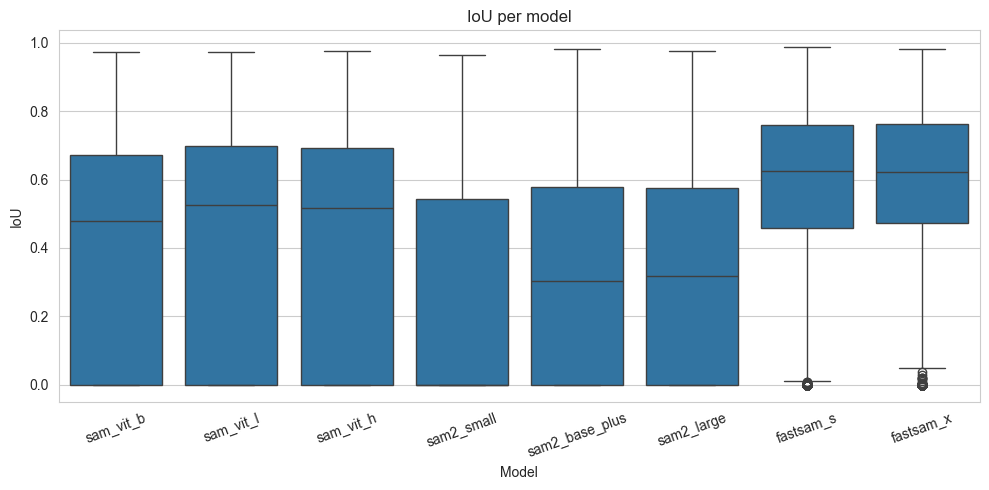

In [22]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 5))
ax = sns.boxplot(data=benchmark_df, x="model", y="iou")
ax.set_title("IoU per model")
ax.set_xlabel("Model")
ax.set_ylabel("IoU")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

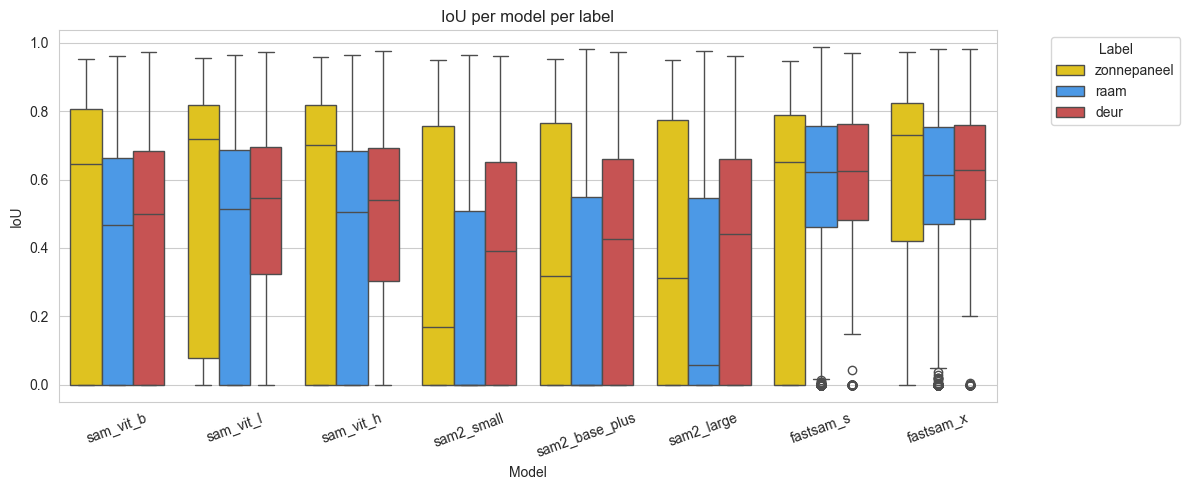

In [23]:
palette = {k: tuple(v) for k, v in LABEL_COLORS.items()}

plt.figure(figsize=(12, 5))

ax = sns.boxplot(
    data=benchmark_df,
    x="model",
    y="iou",
    hue="label",
    palette=palette
)

ax.set_title("IoU per model per label")
ax.set_xlabel("Model")
ax.set_ylabel("IoU")
plt.xticks(rotation=20)

ax.legend(
    title="Label",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## Phase 2 — Test one selected model on original / resized / grayscale

This phase keeps the benchmark and the condition analysis separate.

Important:
- The loop runs **per image**, then `original -> resized -> grayscale`
- This makes it easier to compare the three conditions for the same image
- Cache is checked for each `(model, condition, image)` combination


In [24]:

condition_rows = []

spec = MODEL_SPECS[SELECTED_MODEL]
if not os.path.exists(spec["checkpoint"]):
    raise FileNotFoundError(f"Checkpoint not found for {SELECTED_MODEL}: {spec['checkpoint']}")

base_json_files = find_labelme_json_files(ORIGINAL_DIR)

for json_file in base_json_files:
    print("\n" + "=" * 70)
    print(f"IMAGE — {json_file}")
    print("=" * 70)

    for condition, condition_dir in IMAGE_CONDITIONS.items():
        json_path = os.path.join(condition_dir, json_file)

        if not os.path.exists(json_path):
            print(f"Missing json for {json_file} in {condition}")
            continue

        try:
            data, gt_masks = load_gt_masks(json_path)
            if len(gt_masks) == 0:
                continue

            image_filename = data["imagePath"]
            image_path = resolve_image_path(condition_dir, image_filename)
            if image_path is None:
                print(f"Image not found for {json_file} in {condition}")
                continue

            cache_csv_path = get_condition_cache_path(SELECTED_MODEL, condition, image_filename)

            if USE_CACHE and os.path.exists(cache_csv_path):
                cached_df = pd.read_csv(cache_csv_path)
                cached_rows = cached_df.to_dict(orient="records")
                condition_rows.extend(cached_rows)

                if len(cached_df) > 0:
                    first_row = cached_df.iloc[0]
                    print(
                        f"{SELECTED_MODEL} | {condition} | {image_filename} | "
                        f"loaded from cache | GT={first_row.get('n_gt_objects', 'NA')} | "
                        f"Pred={first_row.get('n_filtered_masks', 'NA')}"
                    )
                else:
                    print(f"{SELECTED_MODEL} | {condition} | {image_filename} | loaded from cache")
                continue

            image_rgb = load_image_rgb(image_path)
            t0 = time.time()
            pred_masks, used_ppb = run_model_on_image(SELECTED_MODEL, image_path, image_rgb)
            elapsed = time.time() - t0

            filtered_masks = filter_masks_by_annotation_overlap(pred_masks, gt_masks, iou_threshold=0.3)

            if CONDITION_OVERLAP_MODE == "combine":
                filtered_masks = combine_predictions_per_gt(filtered_masks)

            if condition == "resized":
                orig_json = os.path.join(ORIGINAL_DIR, json_file)
                orig_data, orig_gt_masks = load_gt_masks(orig_json)
                orig_image_path = resolve_image_path(ORIGINAL_DIR, orig_data["imagePath"])
                orig_image_rgb = load_image_rgb(orig_image_path)
                orig_h, orig_w = orig_image_rgb.shape[:2]

                reproj_filtered = []
                for pred in filtered_masks:
                    reproj_filtered.append({
                        **pred,
                        "segmentation": reproject_mask_to_original(
                            pred["segmentation"],
                            orig_w=orig_w,
                            orig_h=orig_h
                        )
                    })

                scored = score_gt_objects_against_predictions(orig_gt_masks, reproj_filtered)
                vis_gt_masks = gt_masks
                n_gt_total = len(orig_gt_masks)
            else:
                scored = score_gt_objects_against_predictions(gt_masks, filtered_masks)
                vis_gt_masks = gt_masks
                n_gt_total = len(gt_masks)

            mean_iou_img = np.mean([r["iou"] for r in scored]) if scored else 0.0
            mean_dice_img = np.mean([r["dice"] for r in scored]) if scored else 0.0

            matched_gt_indices = [r["gt_index"] for r in scored if r["iou"] > 0]
            n_gt_matched = len(set(matched_gt_indices))
            n_gt_missed = n_gt_total - n_gt_matched

            current_rows = []
            for r in scored:
                current_rows.append({
                    "model": SELECTED_MODEL,
                    "condition": condition,
                    "file": image_filename,
                    "json_file": json_file,
                    "label": r["label"],
                    "gt_index": r["gt_index"],
                    "iou": float(r["iou"]),
                    "dice": float(r["dice"]),
                    "n_gt_objects": n_gt_total,
                    "n_gt_matched": n_gt_matched,
                    "n_gt_missed": n_gt_missed,
                    "n_generated_masks": len(pred_masks),
                    "n_filtered_masks": len(filtered_masks),
                    "runtime_sec": float(elapsed),
                    "image_mean_iou": float(mean_iou_img),
                    "image_mean_dice": float(mean_dice_img),
                    "points_per_batch_used": used_ppb,
                    "overlap_mode": CONDITION_OVERLAP_MODE,
                })

            if current_rows:
                pd.DataFrame(current_rows).to_csv(cache_csv_path, index=False)

            condition_rows.extend(current_rows)

            visual_path = get_condition_visual_path(image_filename, SELECTED_MODEL, condition)
            if not os.path.exists(visual_path):
                save_masked_visualization(
                    image_rgb=image_rgb,
                    filtered_masks=filtered_masks,
                    gt_masks=vis_gt_masks,
                    filename=image_filename,
                    output_dir=CONDITION_VIS_DIR,
                    model_name=SELECTED_MODEL,
                    condition=condition,
                )

            print(
                f"{SELECTED_MODEL} | {condition} | {image_filename} | "
                f"GT={n_gt_total} | matched={n_gt_matched} | missed={n_gt_missed} | "
                f"Gen={len(pred_masks)} | Filt={len(filtered_masks)} | "
                f"mean IoU={mean_iou_img:.4f} | time={elapsed:.2f}s"
            )
            cleanup_memory()

        except Exception as e:
            print(f"Error in {condition}/{json_file}: {e}")
            cleanup_memory()

condition_df = pd.DataFrame(condition_rows)
condition_df.to_csv(os.path.join(CONDITION_RESULTS_DIR, "condition_instance_results.csv"), index=False)

display(condition_df.head())



IMAGE — image_10.json
fastsam_x | original | image_10.jpg | loaded from cache | GT=12 | Pred=12
fastsam_x | resized | image_10.jpg | loaded from cache | GT=12 | Pred=8
fastsam_x | grayscale | image_10.jpg | loaded from cache | GT=12 | Pred=9

IMAGE — image_103.json
fastsam_x | original | image_103.jpg | loaded from cache | GT=16 | Pred=33
fastsam_x | resized | image_103.jpg | loaded from cache | GT=16 | Pred=24
fastsam_x | grayscale | image_103.jpg | loaded from cache | GT=16 | Pred=32

IMAGE — image_104.json
fastsam_x | original | image_104.jpg | loaded from cache | GT=12 | Pred=16
fastsam_x | resized | image_104.jpg | loaded from cache | GT=12 | Pred=16
fastsam_x | grayscale | image_104.jpg | loaded from cache | GT=12 | Pred=18

IMAGE — image_105.json
fastsam_x | original | image_105.jpg | loaded from cache | GT=11 | Pred=20
fastsam_x | resized | image_105.jpg | loaded from cache | GT=11 | Pred=18
fastsam_x | grayscale | image_105.jpg | loaded from cache | GT=11 | Pred=20

IMAGE — i

,model,condition,file,json_file,label,gt_index,iou,dice,n_gt_objects,n_gt_matched,n_gt_missed,n_generated_masks,n_filtered_masks,runtime_sec,image_mean_iou,image_mean_dice,points_per_batch_used,overlap_mode
0,fastsam_x,original,image_10.jpg,image_10.json,zonnepaneel,0,0.859523,0.924455,12,7,5,99,12,3.056145,0.363669,0.444931,NaN,best
1,fastsam_x,original,image_10.jpg,image_10.json,zonnepaneel,1,0.000000,0.000000,12,7,5,99,12,3.056145,0.363669,0.444931,NaN,best
2,fastsam_x,original,image_10.jpg,image_10.json,raam,2,0.590622,0.742630,12,7,5,99,12,3.056145,0.363669,0.444931,NaN,best
3,fastsam_x,original,image_10.jpg,image_10.json,raam,3,0.000000,0.000000,12,7,5,99,12,3.056145,0.363669,0.444931,NaN,best
4,fastsam_x,original,image_10.jpg,image_10.json,raam,4,0.692432,0.818268,12,7,5,99,12,3.056145,0.363669,0.444931,NaN,best


## Condition analysis

The cells below summarize the selected-model condition experiment.


In [25]:
df = condition_df

In [26]:
print(df.head())
print()
print(df.sort_values("image_mean_iou", ascending=False))

       model condition          file      json_file        label  gt_index  \
0  fastsam_x  original  image_10.jpg  image_10.json  zonnepaneel         0   
1  fastsam_x  original  image_10.jpg  image_10.json  zonnepaneel         1   
2  fastsam_x  original  image_10.jpg  image_10.json         raam         2   
3  fastsam_x  original  image_10.jpg  image_10.json         raam         3   
4  fastsam_x  original  image_10.jpg  image_10.json         raam         4   

        iou      dice  n_gt_objects  n_gt_matched  n_gt_missed  \
0  0.859523  0.924455            12             7            5   
1  0.000000  0.000000            12             7            5   
2  0.590622  0.742630            12             7            5   
3  0.000000  0.000000            12             7            5   
4  0.692432  0.818268            12             7            5   

   n_generated_masks  n_filtered_masks  runtime_sec  image_mean_iou  \
0                 99                12     3.056145        0.36

In [27]:
pivot_iou = (
    df.groupby(["model", "label"])["iou"]
      .mean()
      .unstack("label")
      .round(4)
)

pivot_dice = (
    df.groupby(["model", "label"])["dice"]
      .mean()
      .unstack("label")
      .round(4)
)

print("Mean IoU per model x label")
display(pivot_iou)

print("Mean Dice per model x label")
display(pivot_dice)

Mean IoU per model x label


label,deur,raam,zonnepaneel
model,,,
fastsam_x,0.5921,0.5786,0.5389


Mean Dice per model x label


label,deur,raam,zonnepaneel
model,,,
fastsam_x,0.7118,0.6964,0.6124


In [28]:
df.head()

,model,condition,file,json_file,label,gt_index,iou,dice,n_gt_objects,n_gt_matched,n_gt_missed,n_generated_masks,n_filtered_masks,runtime_sec,image_mean_iou,image_mean_dice,points_per_batch_used,overlap_mode
0,fastsam_x,original,image_10.jpg,image_10.json,zonnepaneel,0,0.859523,0.924455,12,7,5,99,12,3.056145,0.363669,0.444931,NaN,best
1,fastsam_x,original,image_10.jpg,image_10.json,zonnepaneel,1,0.000000,0.000000,12,7,5,99,12,3.056145,0.363669,0.444931,NaN,best
2,fastsam_x,original,image_10.jpg,image_10.json,raam,2,0.590622,0.742630,12,7,5,99,12,3.056145,0.363669,0.444931,NaN,best
3,fastsam_x,original,image_10.jpg,image_10.json,raam,3,0.000000,0.000000,12,7,5,99,12,3.056145,0.363669,0.444931,NaN,best
4,fastsam_x,original,image_10.jpg,image_10.json,raam,4,0.692432,0.818268,12,7,5,99,12,3.056145,0.363669,0.444931,NaN,best


In [29]:
df["label"] = df["label"].str.lower()
df["condition"] = df["condition"].str.lower()

print(f"\nAmount of rows: {len(df)}")
print(f"Condition: {df['condition'].unique()}")
print(f"Labels: {df['label'].unique()}")


Amount of rows: 13944
Condition: <ArrowStringArray>
['original', 'resized', 'grayscale']
Length: 3, dtype: str
Labels: <ArrowStringArray>
['zonnepaneel', 'raam', 'deur']
Length: 3, dtype: str


In [30]:
summary = df.groupby(["condition", "label"])["iou"].agg(["mean", "std", "count"]).round(4)

print("Mean IoU per condition per label:")
print(summary)

#summary.to_csv(os.path.join(RESULTS_DIR, "iou_summary.csv"))

Mean IoU per condition per label:
                         mean     std  count
condition label                             
grayscale deur         0.5903  0.2294    745
          raam         0.5807  0.2409   3718
          zonnepaneel  0.5450  0.3558    185
original  deur         0.6010  0.2248    745
          raam         0.5809  0.2409   3718
          zonnepaneel  0.5795  0.3345    185
resized   deur         0.5851  0.2254    745
          raam         0.5741  0.2329   3718
          zonnepaneel  0.4923  0.3656    185


In [31]:
pivot = df.groupby(["condition", "label"])["iou"].mean().unstack("condition").round(4)
pivot = pivot[["original", "resized", "grayscale"]]

print("Table for paper (mean IoU):")
print(pivot)

Table for paper (mean IoU):
condition    original  resized  grayscale
label                                    
deur           0.6010   0.5851     0.5903
raam           0.5809   0.5741     0.5807
zonnepaneel    0.5795   0.4923     0.5450


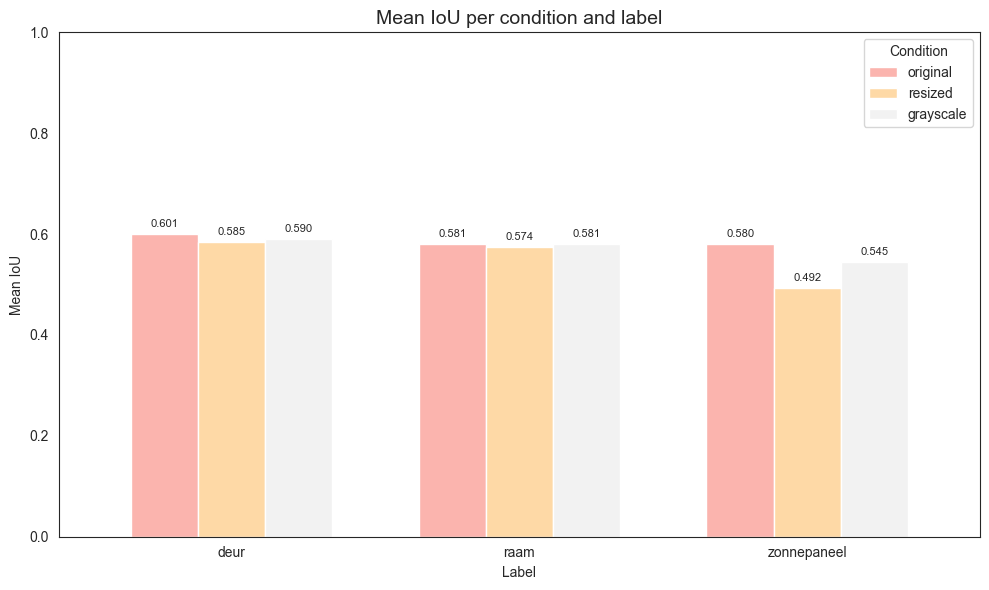

In [32]:
sns.set_style("white")
fig, ax = plt.subplots(figsize=(10, 6))
pivot.plot(kind="bar", ax=ax, colormap="Pastel1", width=0.7)
ax.set_title("Mean IoU per condition and label", fontsize=14)
ax.set_xlabel("Label")
ax.set_ylabel("Mean IoU")
ax.set_ylim(0, 1)
ax.legend(title="Condition")
ax.tick_params(axis="x", rotation=0)
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.text(p.get_x() + p.get_width() / 2, height + 0.01, f"{height:.3f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
#plt.savefig(os.path.join(RESULTS_DIR, "iou_per_label.png"), dpi=150)
plt.show()

In [33]:
df.head()

,model,condition,file,json_file,label,gt_index,iou,dice,n_gt_objects,n_gt_matched,n_gt_missed,n_generated_masks,n_filtered_masks,runtime_sec,image_mean_iou,image_mean_dice,points_per_batch_used,overlap_mode
0,fastsam_x,original,image_10.jpg,image_10.json,zonnepaneel,0,0.859523,0.924455,12,7,5,99,12,3.056145,0.363669,0.444931,NaN,best
1,fastsam_x,original,image_10.jpg,image_10.json,zonnepaneel,1,0.000000,0.000000,12,7,5,99,12,3.056145,0.363669,0.444931,NaN,best
2,fastsam_x,original,image_10.jpg,image_10.json,raam,2,0.590622,0.742630,12,7,5,99,12,3.056145,0.363669,0.444931,NaN,best
3,fastsam_x,original,image_10.jpg,image_10.json,raam,3,0.000000,0.000000,12,7,5,99,12,3.056145,0.363669,0.444931,NaN,best
4,fastsam_x,original,image_10.jpg,image_10.json,raam,4,0.692432,0.818268,12,7,5,99,12,3.056145,0.363669,0.444931,NaN,best


In [34]:
print("Statistical tests (Wilcoxon signed-rank, original vs condition):")

for condition in ["resized", "grayscale"]:
    orig = df[df["condition"] == "original"].set_index(["file", "label"])["iou"]
    cmp = df[df["condition"] == condition].set_index(["file", "label"])["iou"]

    common = orig.index.intersection(cmp.index)
    if len(common) < 5:
        print(f"  Not enough common samples for {condition} (n={len(common)}), test skipped.")
        continue

    stat, p = stats.wilcoxon(orig.loc[common].values, cmp.loc[common].values)
    sig = "significant" if p < 0.05 else "not significant"
    print(f"  Original vs {condition.capitalize()}: p-value = {p:.5f} ({sig})")

Statistical tests (Wilcoxon signed-rank, original vs condition):
  Original vs Resized: p-value = 0.00000 (significant)
  Original vs Grayscale: p-value = 0.28197 (not significant)


In [35]:
print("Relative IoU drop vs. original (%):")

orig_mean = df[df["condition"] == "original"].groupby("label")["iou"].mean()

for condition in ["resized", "grayscale"]:
    cmp_mean = df[df["condition"] == condition].groupby("label")["iou"].mean()
    relative_drop = ((orig_mean - cmp_mean) / orig_mean * 100).round(2)
    print(f"\n     {condition}:")
    for label, pct in relative_drop.items():
        arrow = "▼" if pct < 0 else "▲"
        print(f"       {label}: {arrow} {abs(pct):.2f}%")

Relative IoU drop vs. original (%):

     resized:
       deur: ▲ 2.64%
       raam: ▲ 1.17%
       zonnepaneel: ▲ 15.06%

     grayscale:
       deur: ▲ 1.78%
       raam: ▲ 0.03%
       zonnepaneel: ▲ 5.96%


In [36]:
# List of files that have to be copied to the directory 'not_occluded':

not_occluded_files = [
"image_4.jpg", "image_7.jpg", "image_8.jpg", "image_13.jpg",
"image_15.jpg", "image_18.jpg", "image_19.jpg", "image_23.jpg",
"image_24.jpg", "image_25.jpg", "image_31.jpg", "image_33.jpg",
"image_37.jpg", "image_38.jpg", "image_41.jpg", "image_42.jpg",
"image_43.jpg", "image_46.jpg", "image_48.jpg", "image_49.jpg",
"image_52.jpg", "image_54.jpg", "image_59.jpg", "image_69.jpg",
"image_72.jpg", "image_73.jpg", "image_79.jpg", "image_86.jpg",
"image_87.jpg", "image_91.jpg", "image_93.jpg", "image_95.jpg",
"image_97.jpg", "image_103.jpg", "image_109.jpg", "image_110.jpg",
"image_111.jpg", "image_112.jpg", "image_113.jpg", "image_114.jpg",
"image_126.jpg", "image_146.jpg", "image_148.jpg", "image_151.jpg",
"image_156.jpg", "image_160.jpg", "image_162.jpg", "image_171.jpg",
"image_176.jpg", "image_177.jpg", "image_185.jpg", "image_193.jpg",
"image_207.jpg", "image_208.jpg", "image_209.jpg", "image_210.jpg",
"image_223.jpg", "image_224.jpg", "image_227.jpg", "image_239.jpg",
"image_243.jpg", "image_251.jpg", "image_254.jpg", "image_266.jpg",
"image_267.jpg", "image_268.jpg", "image_275.jpg", "image_278.jpg",
"image_279.jpg", "image_280.jpg", "image_281.jpg", "image_282.jpg",
"image_283.jpg", "image_284.jpg", "image_285.jpg", "image_286.jpg",
"image_287.jpg", "image_289.jpg", "image_292.jpg", "image_293.jpg",
"image_294.jpg", "image_295.jpg", "image_297.jpg", "image_299.jpg",
"image_306.jpg", "image_311.jpg", "image_318.jpg", "image_319.jpg",
"image_322.jpg", "image_327.jpg", "image_329.jpg", "image_332.jpg",
"image_334.jpg", "image_335.jpg", "image_337.jpg", "image_346.jpg",
"image_349.jpg", "image_352.jpg", "image_356.jpg", "image_372.jpg",
"image_374.jpg", "image_376.jpg", "image_385.jpg", "image_393.jpg",
"image_395.jpg", "image_401.jpg", "image_402.jpg", "image_404.jpg",
"image_405.jpg", "image_408.jpg", "image_415.jpg", "image_416.jpg",
"image_417.jpg", "image_424.jpg", "image_427.jpg", "image_428.jpg",
"image_432.jpg", "image_437.jpg", "image_443.jpg", "image_446.jpg",
"image_447.jpg", "image_455.jpg", "image_465.jpg", "image_467.jpg",
"image_469.jpg", "image_470.jpg", "image_473.jpg", "image_477.jpg",
"image_478.jpg", "image_481.jpg", "image_484.jpg", "image_486.jpg",
"image_487.jpg", "image_488.jpg", "image_489.jpg", "image_495.jpg",
"image_496.jpg"
]

# List of files that have to be copied to the directory 'not_occluded', since not all original scraped images are selected to be suitable (like living rooms):

occluded_files = [
"image_9.jpg", "image_10.jpg", "image_14.jpg", "image_17.jpg",
"image_26.jpg", "image_27.jpg", "image_28.jpg", "image_30.jpg",
"image_32.jpg", "image_35.jpg", "image_36.jpg", "image_40.jpg",
"image_44.jpg", "image_45.jpg", "image_47.jpg", "image_51.jpg",
"image_56.jpg", "image_57.jpg", "image_60.jpg", "image_61.jpg",
"image_62.jpg", "image_66.jpg", "image_71.jpg", "image_77.jpg",
"image_78.jpg", "image_80.jpg", "image_81.jpg", "image_82.jpg",
"image_85.jpg", "image_88.jpg", "image_90.jpg", "image_92.jpg",
"image_96.jpg", "image_99.jpg", "image_104.jpg", "image_105.jpg",
"image_107.jpg", "image_123.jpg", "image_124.jpg", "image_129.jpg",
"image_130.jpg", "image_131.jpg", "image_132.jpg", "image_133.jpg",
"image_135.jpg", "image_136.jpg", "image_137.jpg", "image_138.jpg",
"image_139.jpg", "image_141.jpg", "image_147.jpg", "image_157.jpg",
"image_158.jpg", "image_159.jpg", "image_161.jpg", "image_164.jpg",
"image_165.jpg", "image_169.jpg", "image_172.jpg", "image_174.jpg",
"image_175.jpg", "image_179.jpg", "image_180.jpg", "image_182.jpg",
"image_183.jpg", "image_184.jpg", "image_187.jpg", "image_191.jpg",
"image_195.jpg", "image_197.jpg", "image_198.jpg", "image_200.jpg",
"image_201.jpg", "image_202.jpg", "image_204.jpg", "image_206.jpg",
"image_213.jpg", "image_214.jpg", "image_216.jpg", "image_217.jpg",
"image_218.jpg", "image_221.jpg", "image_222.jpg", "image_226.jpg",
"image_228.jpg", "image_231.jpg", "image_232.jpg", "image_234.jpg",
"image_235.jpg", "image_236.jpg", "image_237.jpg", "image_238.jpg",
"image_240.jpg", "image_241.jpg", "image_245.jpg", "image_246.jpg",
"image_249.jpg", "image_255.jpg", "image_257.jpg", "image_258.jpg",
"image_261.jpg", "image_262.jpg", "image_263.jpg", "image_264.jpg",
"image_265.jpg", "image_270.jpg", "image_271.jpg", "image_272.jpg",
"image_273.jpg", "image_274.jpg", "image_276.jpg", "image_277.jpg",
"image_300.jpg", "image_301.jpg", "image_302.jpg", "image_303.jpg",
"image_304.jpg", "image_307.jpg", "image_309.jpg", "image_310.jpg",
"image_312.jpg", "image_313.jpg", "image_317.jpg", "image_321.jpg",
"image_323.jpg", "image_324.jpg", "image_326.jpg", "image_328.jpg",
"image_330.jpg", "image_331.jpg", "image_336.jpg", "image_338.jpg",
"image_339.jpg", "image_340.jpg", "image_347.jpg", "image_350.jpg",
"image_353.jpg", "image_354.jpg", "image_358.jpg", "image_359.jpg",
"image_360.jpg", "image_365.jpg", "image_366.jpg", "image_367.jpg",
"image_368.jpg", "image_369.jpg", "image_370.jpg", "image_373.jpg",
"image_377.jpg", "image_380.jpg", "image_381.jpg", "image_382.jpg",
"image_383.jpg", "image_387.jpg", "image_388.jpg", "image_389.jpg",
"image_391.jpg", "image_394.jpg", "image_398.jpg", "image_403.jpg",
"image_406.jpg", "image_407.jpg", "image_410.jpg", "image_411.jpg",
"image_414.jpg", "image_418.jpg", "image_420.jpg", "image_421.jpg",
"image_423.jpg", "image_425.jpg", "image_426.jpg", "image_429.jpg",
"image_430.jpg", "image_431.jpg", "image_433.jpg", "image_434.jpg",
"image_435.jpg", "image_436.jpg", "image_440.jpg", "image_442.jpg",
"image_445.jpg", "image_448.jpg", "image_449.jpg", "image_450.jpg",
"image_452.jpg", "image_453.jpg", "image_456.jpg", "image_457.jpg",
"image_458.jpg", "image_459.jpg", "image_461.jpg", "image_462.jpg",
"image_463.jpg", "image_466.jpg", "image_471.jpg", "image_479.jpg",
"image_480.jpg", "image_482.jpg", "image_483.jpg", "image_485.jpg",
"image_490.jpg", "image_492.jpg", "image_493.jpg", "image_494.jpg",
"image_497.jpg"  
]


In [37]:
df["condition_2"] = "unknown"

df.loc[df["file"].isin(occluded_files), "condition_2"] = "occluded"
df.loc[df["file"].isin(not_occluded_files), "condition_2"] = "not_occluded"

In [38]:
df_condition2 = df[df['condition'] == 'original']

In [39]:
#df.to_csv("metadata.csv",sep=';')

In [40]:
pivot = (
    df_condition2.groupby(["condition_2", "label"])["iou"]
      .mean()
      .unstack("condition_2")
)

# overall mean per label
overall = df_condition2.groupby("label")["iou"].mean()

# toevoegen als nieuwe kolom
pivot["original"] = overall

# volgorde bepalen
pivot = pivot[["original", "occluded", "not_occluded"]]

pivot = pivot.round(4)

print("Table for paper (mean IoU):")
print(pivot)

Table for paper (mean IoU):
condition_2  original  occluded  not_occluded
label                                        
deur           0.6010    0.5538        0.6726
raam           0.5809    0.5473        0.6329
zonnepaneel    0.5795    0.6239        0.5172


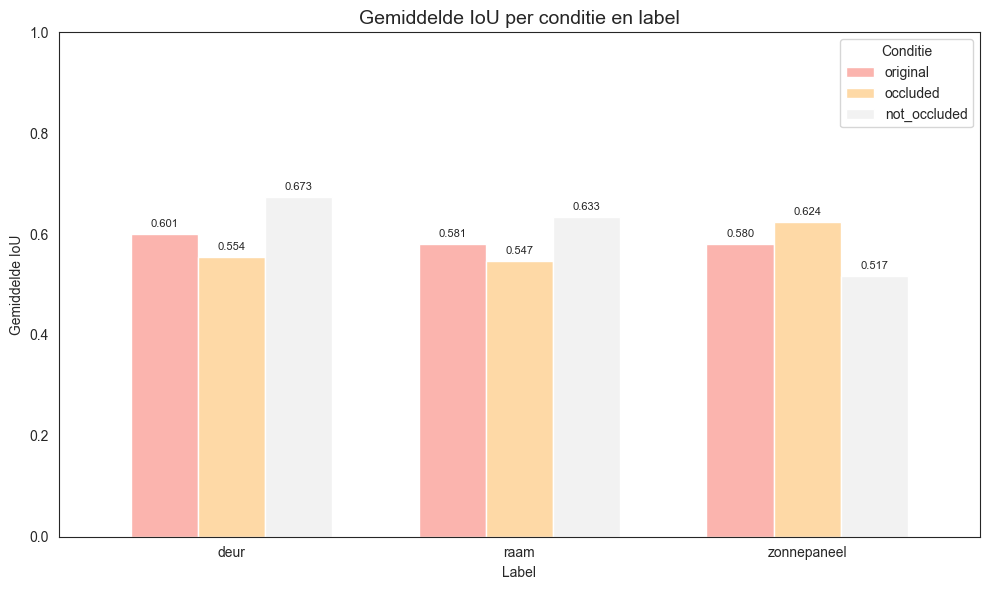

In [41]:
sns.set_style("white")
fig, ax = plt.subplots(figsize=(10, 6))
pivot.plot(kind="bar", ax=ax, colormap="Pastel1", width=0.7)
ax.set_title("Gemiddelde IoU per conditie en label", fontsize=14)
ax.set_xlabel("Label")
ax.set_ylabel("Gemiddelde IoU")
ax.set_ylim(0, 1)
ax.legend(title="Conditie")
ax.tick_params(axis="x", rotation=0)
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.text(p.get_x() + p.get_width() / 2, height + 0.01, f"{height:.3f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
#plt.savefig(os.path.join(RESULTS_DIR, "iou_per_label_occlusion.png"), dpi=150)
plt.show()

In [42]:
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

# Select data
occluded_raw = df_condition2[df_condition2["condition_2"] == "occluded"]["iou"]
not_occluded_raw = df_condition2[df_condition2["condition_2"] == "not_occluded"]["iou"]

# Mann-Whitney
U, p = mannwhitneyu(occluded_raw, not_occluded_raw, alternative='two-sided')

# Rank-biserial correlation
n1 = len(occluded_raw)
n2 = len(not_occluded_raw)
r_rb = 1 - (2 * U) / (n1 * n2)

print(f"U-statistic: {U:.4f}")
print(f"p-waarde:    {p:.6f}")
print(f"Rank-biserial correlation: {r_rb:.4f}")

U-statistic: 2037194.5000
p-waarde:    0.000000
Rank-biserial correlation: 0.2105


In [43]:
labels = df_condition2["label"].unique()

results = []

for label in labels:
    df_label = df_condition2[df_condition2["label"] == label]

    occluded = df_label[df_label["condition_2"] == "occluded"]["iou"]
    not_occluded = df_label[df_label["condition_2"] == "not_occluded"]["iou"]

    if len(occluded) == 0 or len(not_occluded) == 0:
        continue

    U, p = mannwhitneyu(occluded, not_occluded, alternative='two-sided')

    n1 = len(occluded)
    n2 = len(not_occluded)
    r_rb = 1 - (2 * U) / (n1 * n2)

    results.append({
        "label": label,
        "n_occluded": n1,
        "n_not_occluded": n2,
        "U": U,
        "p_value": p,
        "rank_biserial": r_rb,
        "mean_occluded": occluded.mean(),
        "mean_not_occluded": not_occluded.mean(),
    })

results_df = pd.DataFrame(results)

results_df.round(4)

,label,n_occluded,n_not_occluded,U,p_value,rank_biserial,mean_occluded,mean_not_occluded
0,zonnepaneel,108,77,4872.0,0.0459,-0.1717,0.6239,0.5172
1,raam,2257,1461,1305215.0,0.0000,0.2084,0.5473,0.6329
2,deur,449,296,44791.5,0.0000,0.3260,0.5538,0.6726
